# Day 2 EDA — CORD-v2 dataset + Product catalog

**Goal:** understand the data we will pipe through the receipt → cashback system.

Two artefacts are explored here:

1. **CORD-v2** — the public receipts dataset (1000 images + structured
   ground-truth menus) we use for development, evaluation and demo.
2. **`data/catalog.csv`** — our 110-SKU generic F&B catalog that FAISS
   will match line items against.

Decisions checked at the end:

* Is the catalog category mix coherent with what CORD receipts actually
  contain?
* Roughly how many items per receipt will the LLM extractor have to
  return, and FAISS to match?


In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
print('Repo root:', ROOT)


Repo root: C:\Users\alexg\Developers institute\final project


## 1. Load CORD-v2

The dataset is cached locally after the first download (see
`data/README.md`). We load all three splits to see how the corpus is
divided.


In [2]:
ds = load_dataset('naver-clova-ix/cord-v2')
split_sizes = {k: len(ds[k]) for k in ds}
print('Splits and counts:', split_sizes)
print('Total receipts:', sum(split_sizes.values()))
print('Columns per example:', ds['train'].column_names)


Splits and counts: {'train': 800, 'validation': 100, 'test': 100}
Total receipts: 1000
Columns per example: ['image', 'ground_truth']


C:\Users\alexg\AppData\Local\Temp\ipykernel_37696\1732455339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


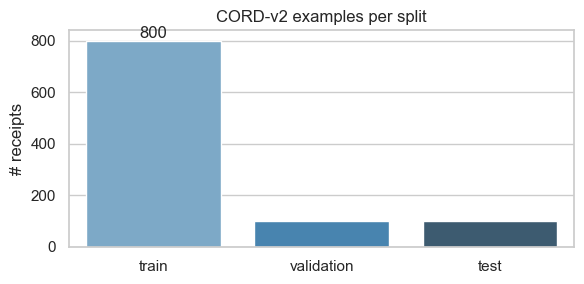

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(
    x=list(split_sizes.keys()),
    y=list(split_sizes.values()),
    ax=ax,
    palette='Blues_d',
)
ax.set_title('CORD-v2 examples per split')
ax.set_ylabel('# receipts')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


## 2. Visual sample of two receipts

We want to eyeball what the OCR will see: layout, image quality, text
orientation, language.


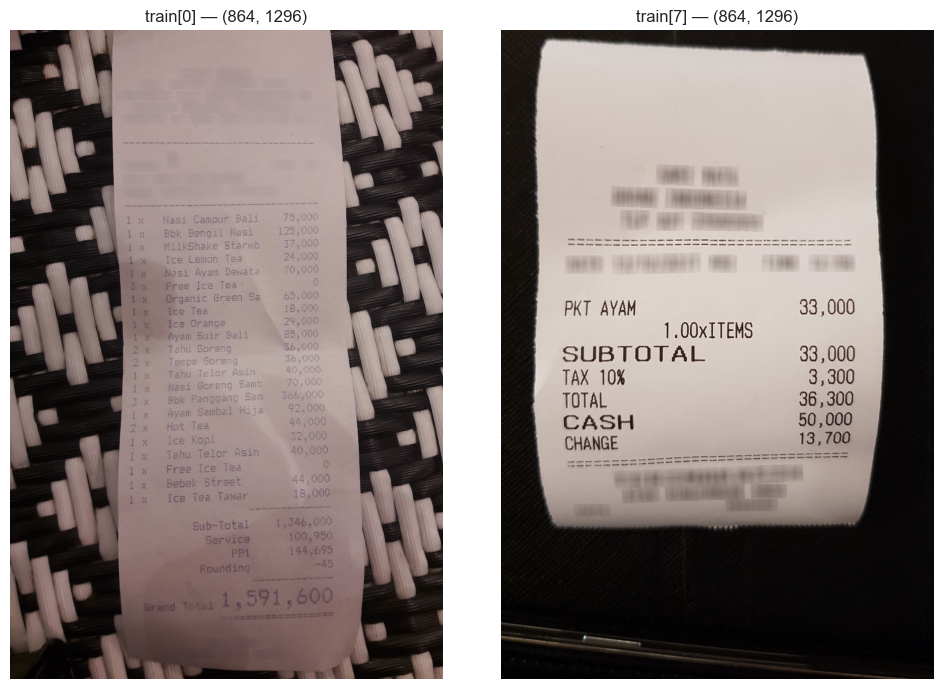

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 7))
for ax, idx in zip(axes, [0, 7]):
    ex = ds['train'][idx]
    ax.imshow(ex['image'])
    ax.set_title(f"train[{idx}] — {ex['image'].size}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Parse all ground-truth line items

Each receipt's `ground_truth` is a JSON string. We extract every line
item (`gt_parse.menu[*].nm`) to characterise:

* how many items per receipt the pipeline must handle
* which items appear most often


In [5]:
def items_from(example):
    gt = json.loads(example['ground_truth'])['gt_parse']
    menu = gt.get('menu', [])
    if isinstance(menu, dict):
        menu = [menu]
    out = []
    for it in menu:
        if isinstance(it, dict) and isinstance(it.get('nm'), str):
            out.append(it['nm'].strip())
    return out

items_per_receipt = [len(items_from(ex)) for ex in ds['train']]
all_items = [nm for ex in ds['train'] for nm in items_from(ex)]
print(f'Total line items (train): {len(all_items):,}')
print(f'Unique item names: {len(set(all_items)):,}')
print(f'Mean items per receipt: {np.mean(items_per_receipt):.2f}')
print(f'Median: {int(np.median(items_per_receipt))}  |  Max: {max(items_per_receipt)}')


Total line items (train): 2,094
Unique item names: 1,479
Mean items per receipt: 2.62
Median: 2  |  Max: 22


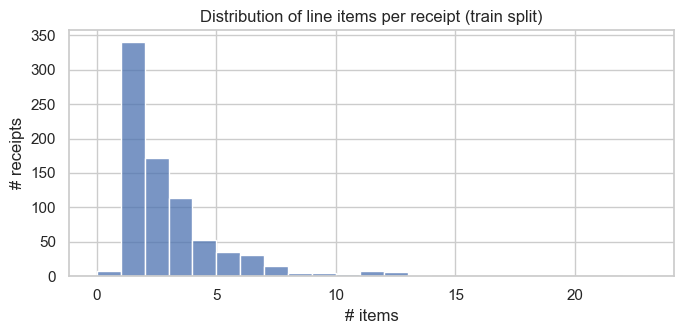

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(items_per_receipt, bins=range(0, max(items_per_receipt) + 2), ax=ax)
ax.set_title('Distribution of line items per receipt (train split)')
ax.set_xlabel('# items')
ax.set_ylabel('# receipts')
plt.tight_layout()
plt.show()


**Reading:** most receipts have 1–3 items, with a long tail up to 30+.
FAISS therefore averages ~2–3 lookups per receipt — fast enough to do
synchronously in the Streamlit handler.


## 4. Top items across the corpus


C:\Users\alexg\AppData\Local\Temp\ipykernel_37696\3487135366.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, y='item', x='count', ax=ax, palette='viridis')


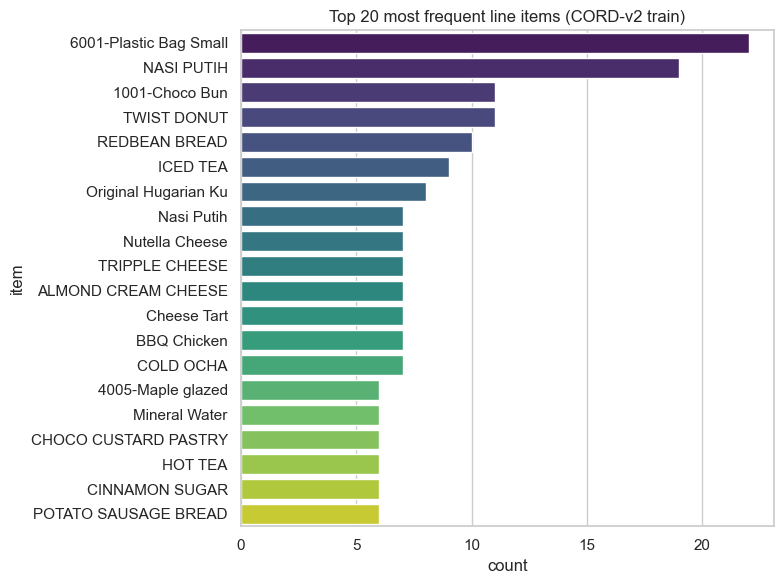

,item,count
0,6001-Plastic Bag Small,22
1,NASI PUTIH,19
2,1001-Choco Bun,11
3,TWIST DONUT,11
4,REDBEAN BREAD,10
5,ICED TEA,9
6,Original Hugarian Ku,8
7,Nasi Putih,7
8,Nutella Cheese,7
9,TRIPPLE CHEESE,7


In [7]:
top = Counter(all_items).most_common(20)
top_df = pd.DataFrame(top, columns=['item', 'count'])
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_df, y='item', x='count', ax=ax, palette='viridis')
ax.set_title('Top 20 most frequent line items (CORD-v2 train)')
plt.tight_layout()
plt.show()
top_df


**Reading:** items are heterogeneous — bread/pastry, drinks (`ICED
TEA`, `MINERAL WATER`), local dishes (`NASI PUTIH`), and even
packaging (`Plastic Bag Small`). This justifies a generic F&B catalog
rather than a brand-specific retail one.


## 5. Product catalog


In [8]:
catalog = pd.read_csv(ROOT / 'data' / 'catalog.csv')
print('Catalog size:', len(catalog))
print('Columns:', list(catalog.columns))
catalog.head()


Catalog size: 110
Columns: ['sku', 'name', 'category', 'subcategory', 'typical_price_usd', 'cashback_rate']


,sku,name,category,subcategory,typical_price_usd,cashback_rate
0,BEV001,Mineral Water,beverage,water,1.5,0.03
1,BEV002,Sparkling Water,beverage,water,2.0,0.03
2,BEV003,Iced Tea,beverage,tea,2.5,0.03
3,BEV004,Hot Tea,beverage,tea,2.0,0.03
4,BEV005,Green Tea,beverage,tea,2.5,0.03


C:\Users\alexg\AppData\Local\Temp\ipykernel_37696\2247697203.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


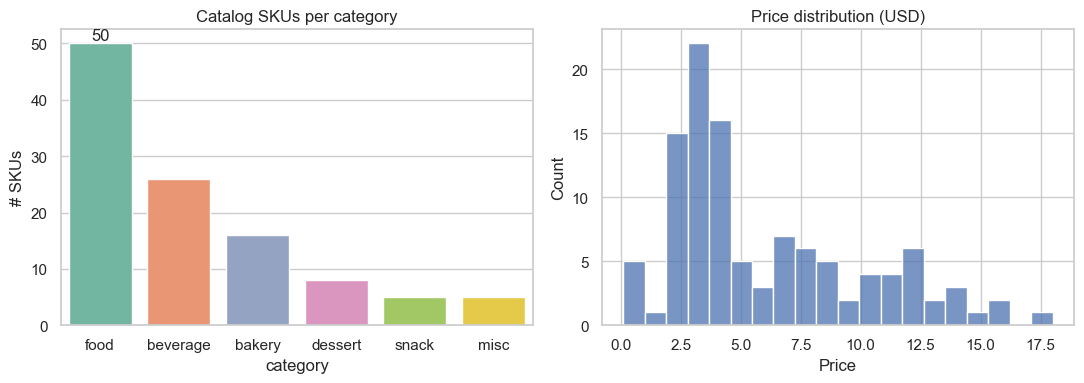

In [9]:
cat_counts = catalog['category'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(
    x=cat_counts.index, y=cat_counts.values,
    ax=axes[0], palette='Set2',
)
axes[0].set_title('Catalog SKUs per category')
axes[0].set_ylabel('# SKUs')
axes[0].bar_label(axes[0].containers[0])

sns.histplot(catalog['typical_price_usd'], bins=20, ax=axes[1])
axes[1].set_title('Price distribution (USD)')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()


C:\Users\alexg\AppData\Local\Temp\ipykernel_37696\2861052003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


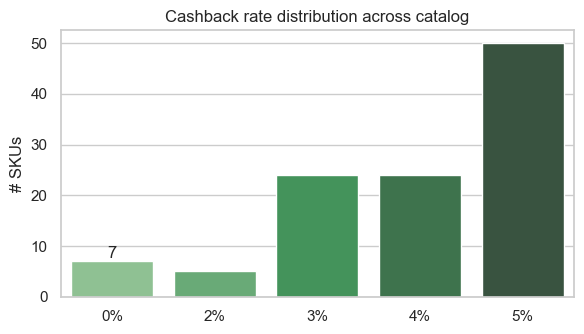

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
rate_counts = catalog['cashback_rate'].value_counts().sort_index()
sns.barplot(
    x=[f'{r*100:.0f}%' for r in rate_counts.index],
    y=rate_counts.values,
    ax=ax,
    palette='Greens_d',
)
ax.set_title('Cashback rate distribution across catalog')
ax.set_ylabel('# SKUs')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


## 6. Decisions confirmed (or revised) by EDA

* CORD-v2 receipts are **restaurant / café / bakery** — generic F&B
  catalog is the right call. A Coca-Cola-style retail catalog would
  have near-zero match rate.
* Receipts average **~2.6 items**, so the FAISS step is cheap.
* The LLM extractor must handle **0–30+ items** per receipt — schema
  has to allow a list of unknown length.
* Catalog already covers the dominant CORD categories (beverages,
  bakery, food, dessert). Misc items (`Plastic Bag`, `Napkins`) are
  represented so FAISS won't return wild matches for packaging lines.
* Cashback rates have a meaningful spread (0% → 5%), enough to make
  the day-7 A/B-test simulation non-trivial.

**Next:** day 3 → OCR pipeline that turns a CORD image into raw text.
